In [6]:
from google.colab import files

uploaded = files.upload()

Saving 2022-01~2023-05_주요 유료관광지점 입장객 수_전체.csv to 2022-01~2023-05_주요 유료관광지점 입장객 수_전체.csv
Saving 2023-06~2024-12_주요 유료관광지점 입장객 수_전체.csv to 2023-06~2024-12_주요 유료관광지점 입장객 수_전체.csv
Saving 2025-01~2026-06_주요 유료관광지점 입장객 수_전체.csv to 2025-01~2026-06_주요 유료관광지점 입장객 수_전체.csv


In [7]:
import os

print(os.listdir('/content'))

['.config', '2022-01~2023-05_주요 유료관광지점 입장객 수_전체.csv', '2025-01~2026-06_주요 유료관광지점 입장객 수_전체.csv', '2023-06~2024-12_주요 유료관광지점 입장객 수_전체.csv', 'sample_data']


In [8]:
import pandas as pd
import glob
import os

In [9]:
files = glob.glob('/content/*.csv')

print('CSV 파일 수:', len(files))

for file in files:
    print(os.path.basename(file))

CSV 파일 수: 3
2022-01~2023-05_주요 유료관광지점 입장객 수_전체.csv
2025-01~2026-06_주요 유료관광지점 입장객 수_전체.csv
2023-06~2024-12_주요 유료관광지점 입장객 수_전체.csv


In [10]:
for file in files:
    temp = pd.read_csv(file, encoding='utf-8-sig')

    print('\n==============================')
    print('파일:', os.path.basename(file))
    print('크기:', temp.shape)
    print('컬럼:', temp.columns.tolist())
    print('------------------------------')
    print(temp.head(3))


파일: 2022-01~2023-05_주요 유료관광지점 입장객 수_전체.csv
크기: (170, 7)
컬럼: ['순위', '광역지자체명', '기초지자체명', '관광지명', '기준연월', '입장객수', '입장객총계']
------------------------------
   순위 광역지자체명 기초지자체명     관광지명    기준연월   입장객수      입장객총계
0   1  부산광역시    기장군  국립부산과학관  202201  53521  1114118.0
1   1  부산광역시    기장군  국립부산과학관  202202  42358  1114118.0
2   1  부산광역시    기장군  국립부산과학관  202203  26374  1114118.0

파일: 2025-01~2026-06_주요 유료관광지점 입장객 수_전체.csv
크기: (144, 7)
컬럼: ['순위', '광역지자체명', '기초지자체명', '관광지명', '기준연월', '입장객수', '입장객총계']
------------------------------
   순위 광역지자체명 기초지자체명     관광지명    기준연월   입장객수     입장객총계
0   1  부산광역시   해운대구  부산아쿠아리움  202501  53067  892464.0
1   1  부산광역시   해운대구  부산아쿠아리움  202502  50149  892464.0
2   1  부산광역시   해운대구  부산아쿠아리움  202503  49915  892464.0

파일: 2023-06~2024-12_주요 유료관광지점 입장객 수_전체.csv
크기: (171, 7)
컬럼: ['순위', '광역지자체명', '기초지자체명', '관광지명', '기준연월', '입장객수', '입장객총계']
------------------------------
   순위 광역지자체명 기초지자체명     관광지명    기준연월    입장객수      입장객총계
0   1  부산광역시    기장군  국립부산과학관  202306   61194  151863

In [11]:
df_list = []

for file in files:
    temp = pd.read_csv(file, encoding='utf-8-sig')
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

print('전체 데이터 크기:', df.shape)

전체 데이터 크기: (485, 7)


In [12]:
df.head()

,순위,광역지자체명,기초지자체명,관광지명,기준연월,입장객수,입장객총계
0,1,부산광역시,기장군,국립부산과학관,202201,53521,1114118.0
1,1,부산광역시,기장군,국립부산과학관,202202,42358,1114118.0
2,1,부산광역시,기장군,국립부산과학관,202203,26374,1114118.0
3,1,부산광역시,기장군,국립부산과학관,202204,42706,1114118.0
4,1,부산광역시,기장군,국립부산과학관,202205,61376,1114118.0


In [13]:
df['기준연월'] = df['기준연월'].astype(str)

df['연월'] = pd.to_datetime(
    df['기준연월'],
    format='%Y%m'
)

In [14]:
print(df['연월'].min())
print(df['연월'].max())

2022-01-01 00:00:00
2026-06-01 00:00:00


In [15]:
df = df[
    (df['연월'] >= '2023-01-01') &
    (df['연월'] <= '2026-06-01')
].copy()

In [16]:
df = df[
    ['기초지자체명', '관광지명', '연월', '입장객수']
].copy()

In [17]:
df['입장객수'] = pd.to_numeric(
    df['입장객수'],
    errors='coerce'
)

In [18]:
print(df['입장객수'].isna().sum())

56


In [19]:
for file in files:
    temp = pd.read_csv(file, encoding='utf-8-sig')

    converted = pd.to_numeric(temp['입장객수'], errors='coerce')

    if converted.isna().sum() > 0:
        print('\n파일:', os.path.basename(file))
        print(temp.loc[converted.isna(), ['기초지자체명', '관광지명', '기준연월', '입장객수']].to_string())


파일: 2022-01~2023-05_주요 유료관광지점 입장객 수_전체.csv
    기초지자체명         관광지명    기준연월 입장객수
102     중구  용두산공원(부산타워)  202201    -
103     중구  용두산공원(부산타워)  202202    -
104     중구  용두산공원(부산타워)  202203    -
105     중구  용두산공원(부산타워)  202204    -
106     중구  용두산공원(부산타워)  202205    -
107     중구  용두산공원(부산타워)  202206    -
108     중구  용두산공원(부산타워)  202207    -
109     중구  용두산공원(부산타워)  202208    -
110     중구  용두산공원(부산타워)  202209    -
111     중구  용두산공원(부산타워)  202210    -
112     중구  용두산공원(부산타워)  202211    -
113     중구  용두산공원(부산타워)  202212    -
148     북구      기후변화체험관  202301    -
149     북구      기후변화체험관  202302    -
150     북구      기후변화체험관  202303    -
151     북구      기후변화체험관  202304    -
152     북구      기후변화체험관  202305    -

파일: 2025-01~2026-06_주요 유료관광지점 입장객 수_전체.csv
    기초지자체명              관광지명    기준연월 입장객수
15    해운대구           부산아쿠아리움  202604    -
16    해운대구           부산아쿠아리움  202605    -
17    해운대구           부산아쿠아리움  202606    -
33     강서구  한국마사회 렛츠런파크 부산경남  202604    -
34     강서구  한국마사회 렛츠런파크 부산경남  202605

In [20]:
monthly = (
    df.groupby(
        ['기초지자체명', '연월'],
        as_index=False
    )['입장객수']
    .sum()
)

In [21]:
print(monthly.head(20))
print(monthly.shape)

   기초지자체명         연월     입장객수
0     강서구 2023-01-01  38203.0
1     강서구 2023-02-01  53639.0
2     강서구 2023-03-01  58807.0
3     강서구 2023-04-01  69208.0
4     강서구 2023-05-01  58320.0
5     강서구 2023-06-01  56613.0
6     강서구 2023-07-01  68590.0
7     강서구 2023-08-01  54745.0
8     강서구 2023-09-01  54723.0
9     강서구 2023-10-01  59192.0
10    강서구 2023-11-01  52440.0
11    강서구 2023-12-01  72000.0
12    강서구 2024-01-01  56604.0
13    강서구 2024-02-01  43411.0
14    강서구 2024-03-01  75477.0
15    강서구 2024-04-01  58469.0
16    강서구 2024-05-01  67205.0
17    강서구 2024-06-01  60723.0
18    강서구 2024-07-01  51219.0
19    강서구 2024-08-01  58896.0
(276, 3)


In [22]:
monthly_count = (
    df.groupby(
        ['기초지자체명', '연월']
    )['관광지명']
    .nunique()
    .reset_index()
)

monthly_count = monthly_count.rename(
    columns={'관광지명': '관광지수'}
)

In [23]:
print(monthly_count.head(20))

   기초지자체명         연월  관광지수
0     강서구 2023-01-01     1
1     강서구 2023-02-01     1
2     강서구 2023-03-01     1
3     강서구 2023-04-01     1
4     강서구 2023-05-01     1
5     강서구 2023-06-01     1
6     강서구 2023-07-01     1
7     강서구 2023-08-01     1
8     강서구 2023-09-01     1
9     강서구 2023-10-01     1
10    강서구 2023-11-01     1
11    강서구 2023-12-01     1
12    강서구 2024-01-01     1
13    강서구 2024-02-01     1
14    강서구 2024-03-01     1
15    강서구 2024-04-01     1
16    강서구 2024-05-01     1
17    강서구 2024-06-01     1
18    강서구 2024-07-01     1
19    강서구 2024-08-01     1


In [24]:
monthly = monthly.merge(
    monthly_count,
    on=['기초지자체명', '연월'],
    how='left'
)

In [25]:
print(monthly.head(20))
print(monthly.shape)

   기초지자체명         연월     입장객수  관광지수
0     강서구 2023-01-01  38203.0     1
1     강서구 2023-02-01  53639.0     1
2     강서구 2023-03-01  58807.0     1
3     강서구 2023-04-01  69208.0     1
4     강서구 2023-05-01  58320.0     1
5     강서구 2023-06-01  56613.0     1
6     강서구 2023-07-01  68590.0     1
7     강서구 2023-08-01  54745.0     1
8     강서구 2023-09-01  54723.0     1
9     강서구 2023-10-01  59192.0     1
10    강서구 2023-11-01  52440.0     1
11    강서구 2023-12-01  72000.0     1
12    강서구 2024-01-01  56604.0     1
13    강서구 2024-02-01  43411.0     1
14    강서구 2024-03-01  75477.0     1
15    강서구 2024-04-01  58469.0     1
16    강서구 2024-05-01  67205.0     1
17    강서구 2024-06-01  60723.0     1
18    강서구 2024-07-01  51219.0     1
19    강서구 2024-08-01  58896.0     1
(276, 4)


In [26]:
busan_gu = [
    '중구', '서구', '동구', '영도구',
    '부산진구', '동래구', '남구', '북구',
    '해운대구', '사하구', '금정구', '강서구',
    '연제구', '수영구', '사상구', '기장군'
]

In [27]:
dates = pd.date_range(
    start='2023-01-01',
    end='2026-06-01',
    freq='MS'
)

print('월 개수:', len(dates))

월 개수: 42


In [28]:
base = pd.MultiIndex.from_product(
    [busan_gu, dates],
    names=['기초지자체명', '연월']
).to_frame(index=False)

print(base.shape)
print(base.head())

(672, 2)
  기초지자체명         연월
0     중구 2023-01-01
1     중구 2023-02-01
2     중구 2023-03-01
3     중구 2023-04-01
4     중구 2023-05-01


In [32]:
monthly_full = base.merge(
    monthly,
    on=['기초지자체명', '연월'],
    how='left'
)

# 연월 변환
monthly_full['연월'] = monthly_full['연월'].dt.strftime('%Y%m')

# 컬럼명 변경
monthly_full = monthly_full.rename(columns={
    '기초지자체명': '구군',
    '입장객수': '주요유료관광지입장객수',
    '관광지수': '집계관광지수'
})

print(monthly_full.shape)
print(monthly_full.head())

(672, 4)
   구군      연월  주요유료관광지입장객수  집계관광지수
0  중구  202301      19964.0     1.0
1  중구  202302      21305.0     1.0
2  중구  202303      18524.0     1.0
3  중구  202304      24657.0     1.0
4  중구  202305      27810.0     1.0


In [33]:
monthly_full = monthly_full.rename(columns={
    '기초지자체명': '구군',
    '입장객수': '주요유료관광지입장객수',
    '관광지수': '집계관광지수'
})

print(monthly_full.head())
print(monthly_full.columns)

   구군      연월  주요유료관광지입장객수  집계관광지수
0  중구  202301      19964.0     1.0
1  중구  202302      21305.0     1.0
2  중구  202303      18524.0     1.0
3  중구  202304      24657.0     1.0
4  중구  202305      27810.0     1.0
Index(['구군', '연월', '주요유료관광지입장객수', '집계관광지수'], dtype='object')


In [ ]:
print(monthly_full.isna().sum())

구군               0
연월               0
주요유료관광지입장객수    396
집계관광지수         396
dtype: int64


In [34]:
monthly_full.to_csv(
    '/content/busan_tourist_monthly_2023_2026.csv',
    index=False,
    encoding='utf-8-sig'
)

print('저장 완료')

저장 완료


In [35]:
from google.colab import files

files.download('/content/busan_tourist_monthly_2023_2026.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

font = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = font.get_name()
plt.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
print(os.path.exists('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'))

True


/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/1077736159.py:17: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_

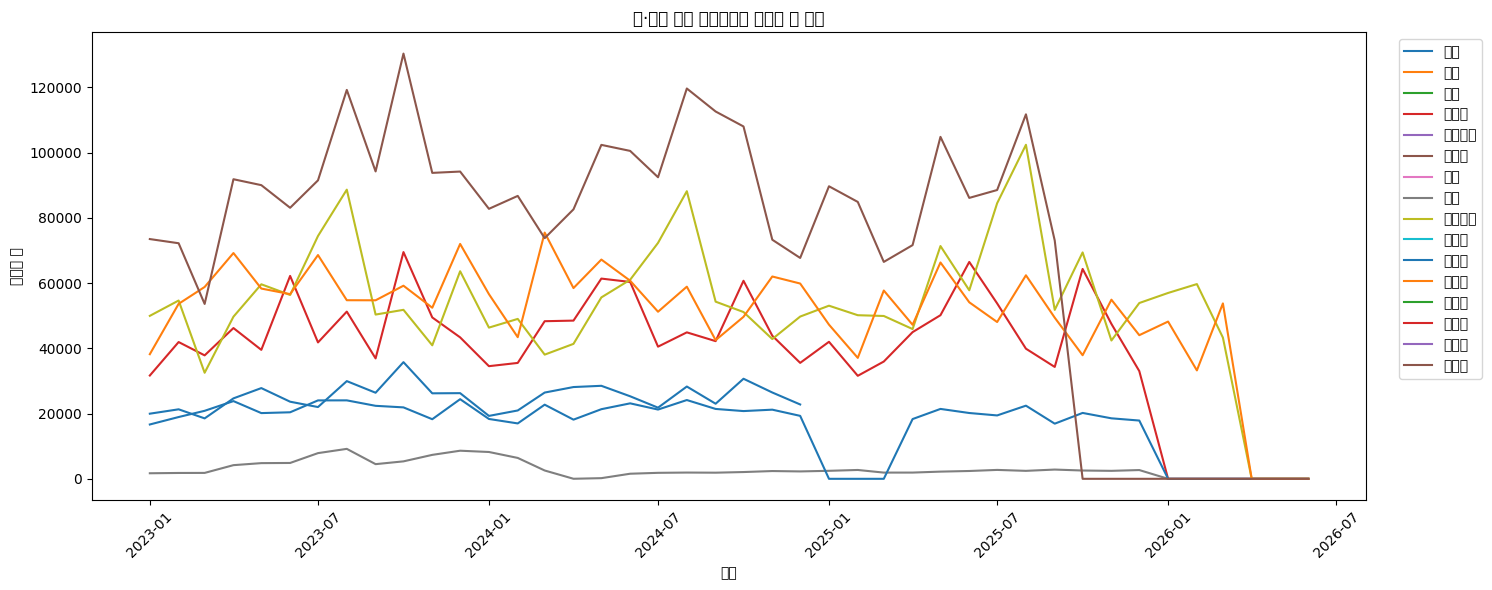

In [ ]:
plt.figure(figsize=(15, 6))

for gu in monthly_full['구군'].unique():
    temp = monthly_full[monthly_full['구군'] == gu]

    plt.plot(
        temp['연월'],
        temp['주요유료관광지입장객수'],
        label=gu
    )

plt.title('구·군별 주요 유료관광지 입장객 수 추이')
plt.xlabel('연월')
plt.ylabel('입장객 수')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 50868 (\N{HANGUL SYLLABLE UN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1325/3002631983.py:24: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) DejaVu Sans.
  plt.tight_lay

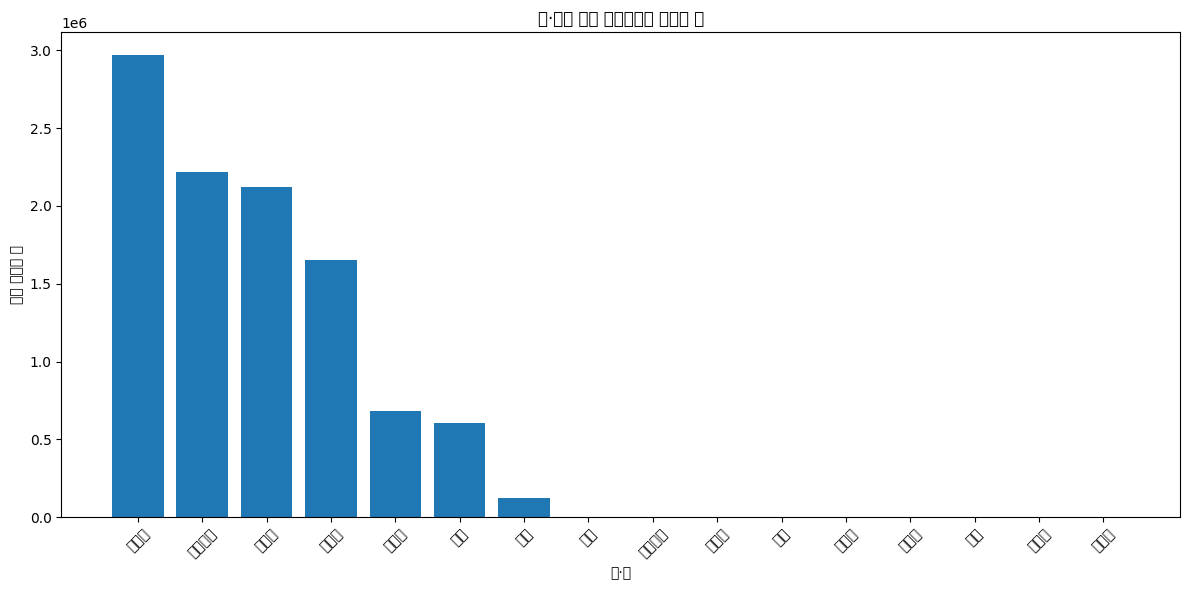

In [ ]:
gu_total = (
    monthly_full
    .groupby('구군', as_index=False)['주요유료관광지입장객수']
    .sum()
    .sort_values(
        '주요유료관광지입장객수',
        ascending=False
    )
)

plt.figure(figsize=(12, 6))

plt.bar(
    gu_total['구군'],
    gu_total['주요유료관광지입장객수']
)

plt.title('구·군별 주요 유료관광지 입장객 수')
plt.xlabel('구·군')
plt.ylabel('누적 입장객 수')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import os

# 폰트 파일 경로
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트 파일 확인
print(os.path.exists(font_path))

# Matplotlib에 폰트 직접 등록
fm.fontManager.addfont(font_path)

# 폰트 이름 확인
font_name = fm.FontProperties(fname=font_path).get_name()
print('사용할 폰트:', font_name)

# Matplotlib 설정
mpl.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

True
사용할 폰트: NanumGothic


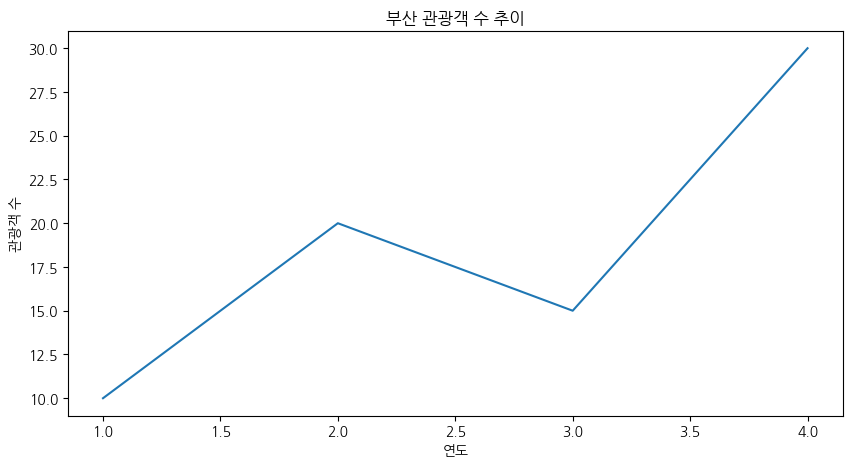

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot([1, 2, 3, 4], [10, 20, 15, 30])

plt.title('부산 관광객 수 추이')
plt.xlabel('연도')
plt.ylabel('관광객 수')

plt.show()

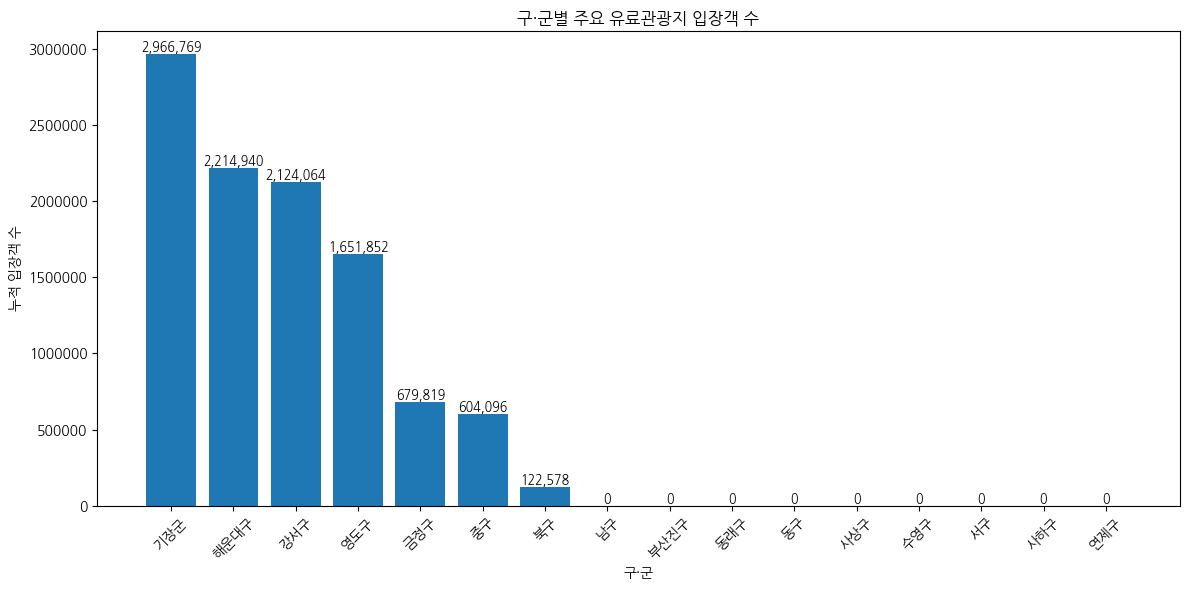

In [ ]:
from matplotlib.ticker import ScalarFormatter

gu_total = (
    monthly_full
    .groupby('구군', as_index=False)['주요유료관광지입장객수']
    .sum()
    .sort_values(
        '주요유료관광지입장객수',
        ascending=False
    )
)

plt.figure(figsize=(12, 6))

bars = plt.bar(
    gu_total['구군'],
    gu_total['주요유료관광지입장객수']
)

plt.title('구·군별 주요 유료관광지 입장객 수')
plt.xlabel('구·군')
plt.ylabel('누적 입장객 수')

plt.xticks(rotation=45)

# Y축을 과학적 표기 대신 실제 숫자로 표시
plt.gca().yaxis.set_major_formatter(
    ScalarFormatter(useOffset=False)
)

plt.ticklabel_format(
    style='plain',
    axis='y'
)
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()